In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Step#1: Read an image using the OpenCV library
If you run the preceding program, you will see an image being displayed in a new window.

In [42]:
img = cv2.imread('cat.jpg')
cv2.imshow('Input image', img)
cv2.waitKey()

print(type(img))

<class 'numpy.ndarray'>


### Step#2: Load an image
To convert a color image in grayscale mode. This operation is performed while reading
the image

In [43]:
gray_img = cv2.imread('cat.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('Grayscale', gray_img)
cv2.waitKey()

-1

### Step#3: Save an image.
The below code of OpenCV is used to save an image file.

In [44]:
cv2.imwrite('images/output.jpg', gray_img)

False

### Step#4: Convert an image to different color spaces
If you already read an image and want to convert it into GrayScal. You can use the below
code.

In [45]:
img = cv2.imread('cat.jpg')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.imshow('Grayscale image', gray_img)
cv2.waitKey()

-1

Considering all the color spaces, there are around 190 conversation options available in
OpenCV. If you want to see a list of all available flags,
The following code will display all the options available in Open-CV related to color handling.

In [46]:
print([x for x in dir(cv2) if x.startswith('COLOR_')])

['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA', 'COLOR_BAYER_GB2BGR_EA', 'COLOR_BAYER_GB2BGR_VNG', 'COLOR_BAYER_GB2GRAY', 'COLOR_BAYER_GB2RGB', 'COLOR_BAYER_GB2RGBA', 'COLOR_BAYER_GB2RGB_EA', 'COLOR_BAYER_GB2RGB_VNG', 'COLOR_BAYER_GBRG2BGR', 'COLOR_BAYER_GBRG2BGRA', 'COLOR_BAYER_GBRG2BGR_EA', 'COLOR_BAYER_GBRG2BGR_VNG', 'COLOR_BAYER_GBRG2GRAY', 'COLOR_BAYER_GBRG2RGB', 'COLOR_BAYER_GBRG2RGBA', 'COLOR_BAYER_GBRG2RGB_EA', 'COLOR_BAYER_GBRG2RGB_VNG', 'COLOR_BAYER_GR2BGR', 'COLOR_BAYER_GR2BGRA', 'COLOR_BAYER_GR2BGR_EA', 'COLOR_BAYER_GR2BGR_VNG', 'COLOR_

You can convert to YUV by using the following flag: (YUV is another color model used to
display color for Televisions. Y: physical linear-space brightness, U: blue projection, V: red
projection.

In [47]:
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

To separate out the three channels, write the following lines:

In [48]:
cv2.imshow('Y channel', yuv_img[:, :, 0])
cv2.imshow('U channel', yuv_img[:, :, 1])
cv2.imshow('V channel', yuv_img[:, :, 2])
cv2.waitKey()

-1

### Task1: Use any image processing library and apply the following geometric transformations over the image.

#### 1. Increase the size of the image.
#### 2. Rotate the image by 120 degrees.
#### 3. Perform Sheer operations over the image.

To show that the image size has been increase: 
Original size: (531, 612)
Enlarged size: (796, 918)


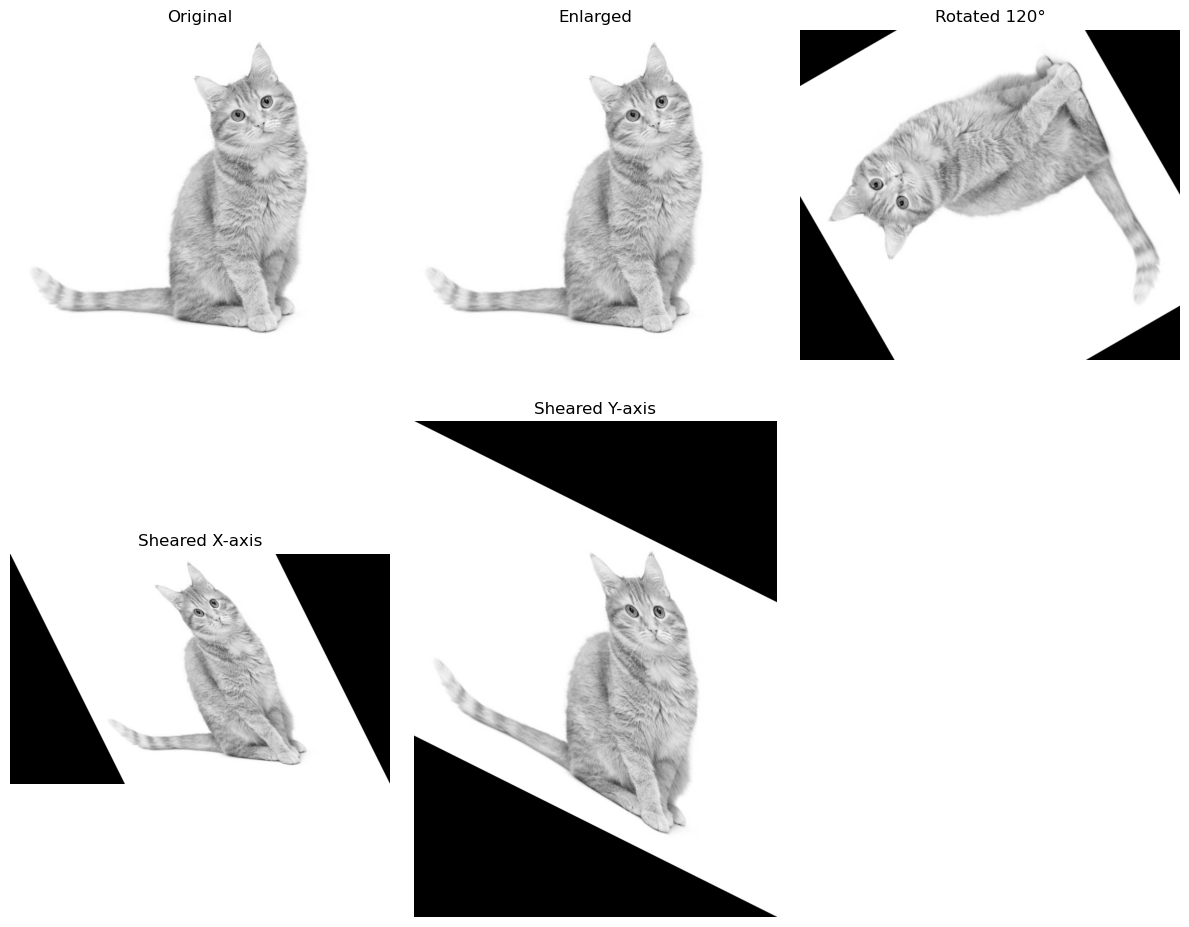

In [49]:
img = cv2.imread("cat.jpg", 0)

# 1️- Increase Image Size (Scaling)

img_enlarged = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)
print("To show that the image size has been increase: ")
print("Original size:", img.shape)
print("Enlarged size:", img_enlarged.shape)


# 2️- Rotate Image by 120 Degrees
rows, cols = img.shape
M_rot = cv2.getRotationMatrix2D((cols/2, rows/2), 120, 1)
img_rotated = cv2.warpAffine(img, M_rot, (cols, rows))


# 3️- Shear Transformation 
# Shear X-axis
M_shear_x = np.float32([[1, 0.5, 0], [0, 1, 0]])
img_shear_x = cv2.warpAffine(img, M_shear_x, (int(cols + 0.5*rows), rows))

# Shear Y-axis
M_shear_y = np.float32([[1, 0, 0], [0.5, 1, 0]])
img_shear_y = cv2.warpAffine(img, M_shear_y, (cols, int(rows + 0.5*cols)))


# Display the results :

plt.figure(figsize=(12,10))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(img_enlarged, cmap='gray')
plt.title("Enlarged")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(img_rotated, cmap='gray')
plt.title("Rotated 120°")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(img_shear_x, cmap='gray')
plt.title("Sheared X-axis")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(img_shear_y, cmap='gray')
plt.title("Sheared Y-axis")
plt.axis("off")

plt.tight_layout()
plt.show()

### Task2: Use any image processing library and apply the following intensity transformations over the image.
#### 1. Negative
#### 2. Log with (choose an appropriate constant for your image)
#### 3. Power law (choose a value for gamma that increases the contrast)

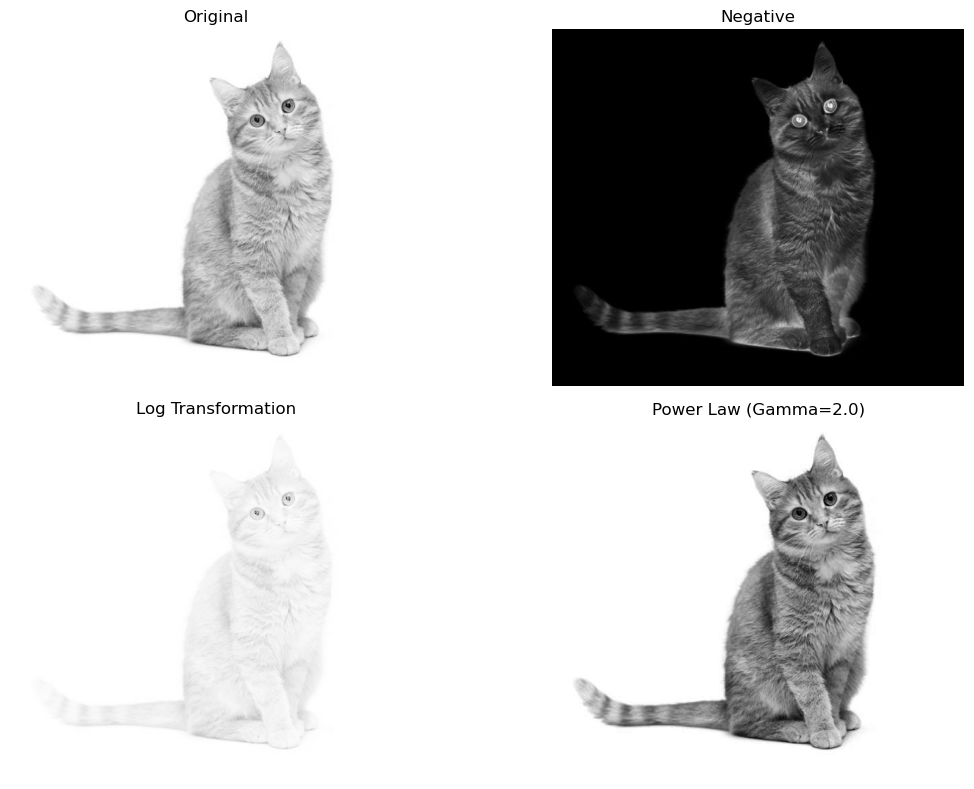

In [50]:
# it is used to convert the image to float to avoid overflow
img_float = img.astype(np.float32)

# 1️- Negative
negative = 255 - img

# 2️- Log Transformation
c = 255 / np.log(1 + np.max(img_float))
log_transformed = c * np.log(1 + img_float)
log_transformed = np.uint8(np.clip(log_transformed, 0, 255))


# 3️- Power Law 

gamma = 2.0  
normalized = img_float  / 255.0
power_law = np.power(normalized, gamma)
power_law = np.uint8(power_law * 255)


# Display the results :

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(negative, cmap='gray')
plt.title("Negative")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(log_transformed, cmap='gray')
plt.title("Log Transformation")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(power_law, cmap='gray')
plt.title("Power Law (Gamma=2.0)")
plt.axis("off")

plt.tight_layout()
plt.show()